<a href="https://colab.research.google.com/github/LesegoMasilela/financial-transaction-analysis/blob/main/Financial_Transaction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Transaction Analysis

## Overview
This project analyzes financial transaction data to identify spending patterns, detect potential fraud, and generate business insights.

## Objectives
- Understand customer behavior
- Detect high-risk transactions
- Perform customer segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/transactions.csv")
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

df.shape

(2512, 16)

In [7]:
# Average and total spending
avg_spending = df['TransactionAmount'].mean()
total_spending = df['TransactionAmount'].sum()

print("Average transaction:", avg_spending)
print("Total spending:", total_spending)

Average transaction: 297.5937778662421
Total spending: 747555.5700000001


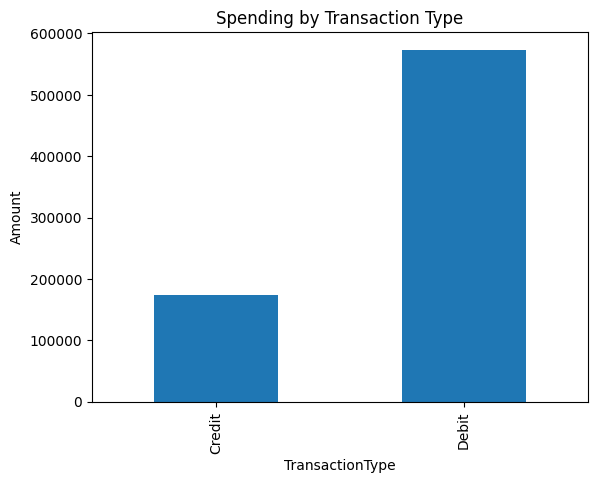

In [9]:
spending_by_category = df.groupby('TransactionType')['TransactionAmount'].sum()

spending_by_category.plot(kind='bar')
plt.title("Spending by Transaction Type")
plt.ylabel("Amount")
plt.show()

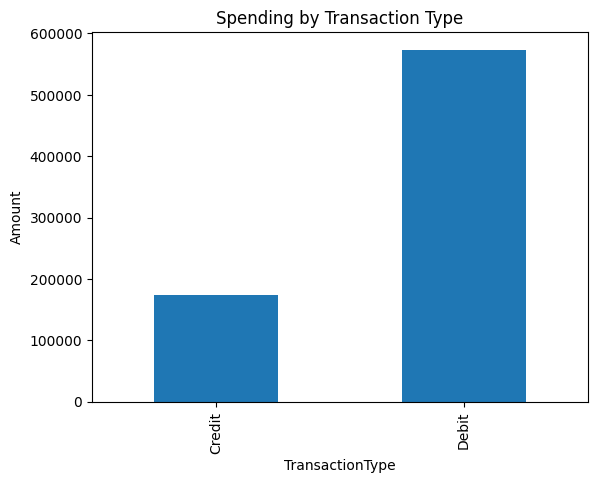

In [11]:
spending_by_category = df.groupby('TransactionType')['TransactionAmount'].sum()

spending_by_category.plot(kind='bar')
plt.title("Spending by Transaction Type")
plt.ylabel("Amount")
plt.show()

In [13]:
customer_spending = df.groupby('AccountID')['TransactionAmount'].sum()

low = customer_spending[customer_spending < 1000]
medium = customer_spending[(customer_spending >= 1000) & (customer_spending < 5000)]
high = customer_spending[customer_spending >= 5000]

print("Low-value customers:", len(low))
print("Medium-value customers:", len(medium))
print("High-value customers:", len(high))

Low-value customers: 169
Medium-value customers: 325
High-value customers: 1


## Key Insights

- Most transactions fall within a normal spending range.
- High-value transactions may indicate potential fraud risk.
- Spending varies significantly across categories.
- Customer segmentation helps identify high-value clients and risk groups.

## Conclusion
This analysis demonstrates how data can be used in financial systems to improve decision-making, detect anomalies, and better understand customer behavior.
